<a href="https://colab.research.google.com/github/sevaradevoloper/machine-learning-class-work/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22lightgboosting%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kaggle lightgbm

In [ ]:
import os
import warnings

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error,
    r2_score
)

import lightgbm as lgb
from lightgbm import LGBMRegressor

warnings.filterwarnings('ignore')

RANDOM_STATE = 42

In [ ]:
from google.colab import files
files.upload()

Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"kaggledotnet1","key":"046269f674425319b5b34777cd59d223"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d neomatrix369/nyc-taxi-trip-duration-extended

Dataset URL: https://www.kaggle.com/datasets/neomatrix369/nyc-taxi-trip-duration-extended
License(s): CC0-1.0
100% 379M/379M [00:11<00:00, 33.3MB/s]



In [ ]:
!unzip -q nyc-taxi-trip-duration-extended.zip -d taxi_data

In [ ]:
!find taxi_data -maxdepth 2 -type f

taxi_data/test/test.csv
taxi_data/nyc_additional_info.csv
taxi_data/train_extended.csv
taxi_data/train_test_extended.csv
taxi_data/sample_submission/sample_submission.csv
taxi_data/test_extended.csv
taxi_data/train/train.csv


In [ ]:
df = pd.read_csv("/content/taxi_data/train/train.csv")

In [ ]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [ ]:
df.shape

(1458644, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


In [ ]:
df.columns.tolist()

['id',
 'vendor_id',
 'pickup_datetime',
 'dropoff_datetime',
 'passenger_count',
 'pickup_longitude',
 'pickup_latitude',
 'dropoff_longitude',
 'dropoff_latitude',
 'store_and_fwd_flag',
 'trip_duration']

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
vendor_id,1458644.0,1.534950,0.498777,1.000000,1.000000,2.000000,2.000000,2.000000e+00
passenger_count,1458644.0,1.664530,1.314242,0.000000,1.000000,1.000000,2.000000,9.000000e+00
pickup_longitude,1458644.0,-73.973486,0.070902,-121.933342,-73.991867,-73.981743,-73.967331,-6.133553e+01
pickup_latitude,1458644.0,40.750921,0.032881,34.359695,40.737347,40.754101,40.768360,5.188108e+01
dropoff_longitude,1458644.0,-73.973416,0.070643,-121.933304,-73.991325,-73.979752,-73.963013,-6.133553e+01
dropoff_latitude,1458644.0,40.751800,0.035891,32.181141,40.735885,40.754524,40.769810,4.392103e+01
trip_duration,1458644.0,959.492273,5237.431724,1.000000,397.000000,662.000000,1075.000000,3.526282e+06


In [ ]:
TARGET = 'trip_duration'
TARGET in df.columns

True

In [ ]:
df[TARGET].describe().T

,trip_duration
count,1.458644e+06
mean,9.594923e+02
std,5.237432e+03
min,1.000000e+00
25%,3.970000e+02
50%,6.620000e+02
75%,1.075000e+03
max,3.526282e+06


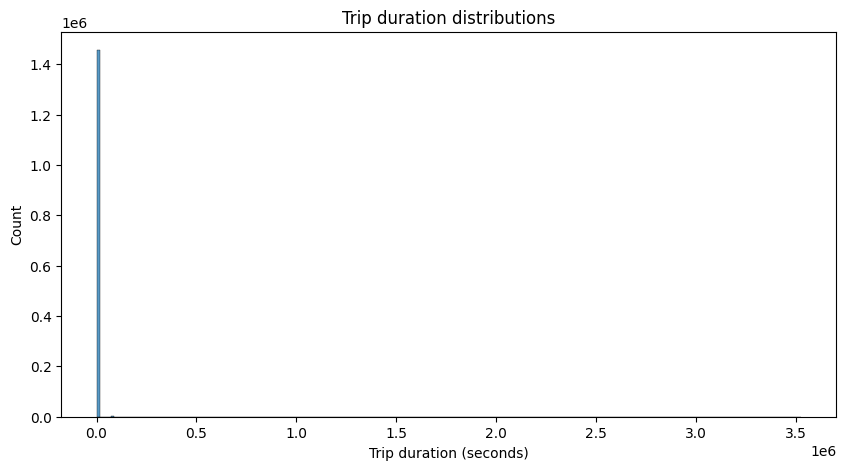

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    df[TARGET],
    bins = 200
)

plt.title("Trip duration distributions")
plt.xlabel("Trip duration (seconds)")
plt.ylabel("Count")

plt.show()

<Axes: xlabel='trip_duration'>

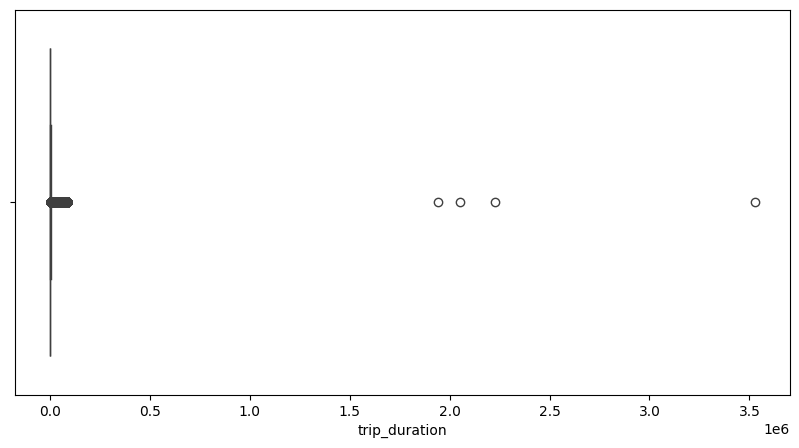

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x = df['trip_duration']
)

In [ ]:
df['log_time_duration'] = np.log1p(df['trip_duration'])

,log_time_duration
0,6.122493
1,6.498282
2,7.661527
3,6.063785
4,6.077642
...,...
1458639,6.658011
1458640,6.486161
1458641,6.639876
1458642,5.924256


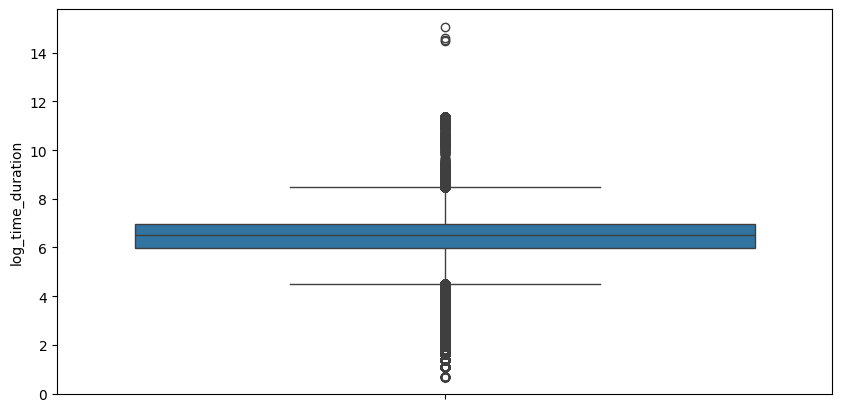

In [ ]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data = df,
    y = df['log_time_duration']
)

plt.show()

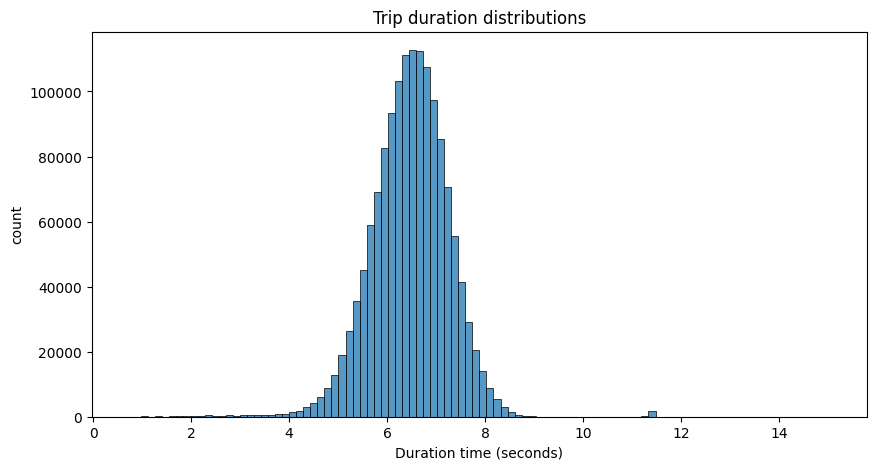

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    x=df['log_time_duration'],
    bins=100,
)

plt.title('Trip duration distributions')
plt.xlabel('Duration time (seconds)')
plt.ylabel('count')

plt.show()

In [ ]:
print("missing valeues")
print(df.isnull().sum())

print("duplicates")
print(df.duplicated().sum())

print("passenger counts")
print(df['passenger_count'].value_counts().sort_index())

print('vendor id')
print(df['vendor_id'].value_counts().sort_index())

print("trip duration statistics")
print(df['trip_duration'].describe())

missing valeues
id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
log_time_duration     0
dtype: int64
duplicates
0
passenger counts
passenger_count
0         60
1    1033540
2     210318
3      59896
4      28404
5      78088
6      48333
7          3
8          1
9          1
Name: count, dtype: int64
vendor id
vendor_id
1    678342
2    780302
Name: count, dtype: int64
trip duration statistics
count    1.458644e+06
mean     9.594923e+02
std      5.237432e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.620000e+02
75%      1.075000e+03
max      3.526282e+06
Name: trip_duration, dtype: float64


In [ ]:
#geographic feature ranges

geo_columns = [
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude"
]

df[geo_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
pickup_longitude,1458644.0,-73.973486,0.070902,-121.933342,-73.991867,-73.981743,-73.967331,-61.335529
pickup_latitude,1458644.0,40.750921,0.032881,34.359695,40.737347,40.754101,40.768360,51.881084
dropoff_longitude,1458644.0,-73.973416,0.070643,-121.933304,-73.991325,-73.979752,-73.963013,-61.335529
dropoff_latitude,1458644.0,40.751800,0.035891,32.181141,40.735885,40.754524,40.769810,43.921028


In [ ]:
# Check suspicious geographic coordinates

print("Pickup longitude:")
print(df["pickup_longitude"].sort_values().head(10))
print(df["pickup_longitude"].sort_values().tail(10))

print("\nPickup latitude:")
print(df["pickup_latitude"].sort_values().head(10))
print(df["pickup_latitude"].sort_values().tail(10))

print("\nDropoff longitude:")
print(df["dropoff_longitude"].sort_values().head(10))
print(df["dropoff_longitude"].sort_values().tail(10))

print("\nDropoff latitude:")
print(df["dropoff_latitude"].sort_values().head(10))
print(df["dropoff_latitude"].sort_values().tail(10))

Pickup longitude:
1184454   -121.933342
1068810   -121.933235
1359910    -79.569733
1430363    -79.487900
595540     -78.547401
193116     -77.896019
952661     -77.440750
233451     -77.039436
801241     -77.039436
1154105    -77.039436
Name: pickup_longitude, dtype: float64
775976    -72.074333
693759    -71.881645
974378    -71.799896
483718    -70.851616
521870    -70.511902
962552    -68.778435
1060807   -66.972160
1387351   -65.897385
782256    -65.848389
804402    -61.335529
Name: pickup_longitude, dtype: float64

Pickup latitude:
782256     34.359695
275644     34.712234
974378     35.081532
775976     35.310307
952661     36.029301
962552     36.118538
1068810    37.389297
1184454    37.389381
193116     37.777771
804402     37.851051
Name: pickup_latitude, dtype: float64
1359910    41.586273
831669     41.687519
837346     41.696796
521870     42.458942
483718     43.017578
1245562    43.139652
165903     43.486885
693759     43.911762
1060807    44.371944
184925     51.88108

In [ ]:
# Approximate NYC bounding box

NYC_LAT_MIN = 40.49
NYC_LAT_MAX = 40.92

NYC_LON_MIN = -74.26
NYC_LON_MAX = -73.70

In [ ]:
# Find rows outside approximate NYC boundaries

geo_outliers = df[
    (df["pickup_latitude"] < NYC_LAT_MIN) |
    (df["pickup_latitude"] > NYC_LAT_MAX) |
    (df["pickup_longitude"] < NYC_LON_MIN) |
    (df["pickup_longitude"] > NYC_LON_MAX) |
    (df["dropoff_latitude"] < NYC_LAT_MIN) |
    (df["dropoff_latitude"] > NYC_LAT_MAX) |
    (df["dropoff_longitude"] < NYC_LON_MIN) |
    (df["dropoff_longitude"] > NYC_LON_MAX)
]

print("Geographic outliers:", len(geo_outliers))
print("Percentage:", len(geo_outliers) / len(df) * 100)

Geographic outliers: 1317
Percentage: 0.09028933722004821


In [ ]:
# Top 20 longest trips

df.nlargest(20, "trip_duration")[
    [
        "id",
        "vendor_id",
        "passenger_count",
        "pickup_datetime",
        "dropoff_datetime",
        "trip_duration"
    ]
]

,id,vendor_id,passenger_count,pickup_datetime,dropoff_datetime,trip_duration
978383,id0053347,1,1,2016-02-13 22:46:52,2016-03-25 18:18:14,3526282
924150,id1325766,1,1,2016-01-05 06:14:15,2016-01-31 01:01:07,2227612
680594,id0369307,1,2,2016-02-13 22:38:00,2016-03-08 15:57:38,2049578
355003,id1864733,1,1,2016-01-05 00:19:42,2016-01-27 11:08:38,1939736
1234291,id1942836,2,2,2016-02-15 23:18:06,2016-02-16 23:17:58,86392
295382,id0593332,2,1,2016-05-31 13:00:39,2016-06-01 13:00:30,86391
73816,id0953667,2,1,2016-05-06 00:00:10,2016-05-07 00:00:00,86390
59891,id2837671,2,1,2016-06-30 16:37:52,2016-07-01 16:37:39,86387
1360439,id1358458,2,1,2016-06-23 16:01:45,2016-06-24 16:01:30,86385
753765,id2589925,2,4,2016-05-17 22:22:56,2016-05-18 22:22:35,86379


In [ ]:
df[[
    "pickup_datetime",
    "dropoff_datetime"
]].dtypes

,0
pickup_datetime,object
dropoff_datetime,object


In [ ]:
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])
df["dropoff_datetime"] = pd.to_datetime(df["dropoff_datetime"])

In [ ]:
df[[
    "pickup_datetime",
    "dropoff_datetime"
]].dtypes

,0
pickup_datetime,datetime64[ns]
dropoff_datetime,datetime64[ns]


In [ ]:
df["datetime_duration"] = (
    df["dropoff_datetime"] - df["pickup_datetime"]
).dt.total_seconds()

In [ ]:
df[
    ["trip_duration", "datetime_duration"]
].head(10)

,trip_duration,datetime_duration
0,455,455.0
1,663,663.0
2,2124,2124.0
3,429,429.0
4,435,435.0
5,443,443.0
6,341,341.0
7,1551,1551.0
8,255,255.0
9,1225,1225.0


In [ ]:
df["duration_difference"] = (
    df["trip_duration"] - df["datetime_duration"]
)

df["duration_difference"].describe()

,duration_difference
count,1458644.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


In [ ]:
(df["datetime_duration"] < 0).sum()

np.int64(0)

In [ ]:
(df["trip_duration"] != df["datetime_duration"]).sum()

np.int64(0)

In [ ]:
duration_quantiles = df["trip_duration"].quantile(
    [0.001, 0.005, 0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999]
)

duration_quantiles

,trip_duration
0.001,7.000
0.005,50.000
0.010,87.000
0.050,180.000
0.250,397.000
0.500,662.000
0.750,1075.000
0.900,1634.000
0.950,2104.000
0.990,3440.000


In [ ]:
duration_quantiles_minutes = duration_quantiles / 60

duration_quantiles_minutes

,trip_duration
0.001,0.116667
0.005,0.833333
0.010,1.450000
0.050,3.000000
0.250,6.616667
0.500,11.033333
0.750,17.916667
0.900,27.233333
0.950,35.066667
0.990,57.333333


In [ ]:
thresholds = [
    30 * 60,        # 30 minutes
    60 * 60,        # 1 hour
    2 * 60 * 60,     # 2 hours
    3 * 60 * 60,     # 3 hours
    6 * 60 * 60,     # 6 hours
    12 * 60 * 60,    # 12 hours
    24 * 60 * 60     # 24 hours
]

for threshold in thresholds:
    count = (df["trip_duration"] > threshold).sum()
    percentage = count / len(df) * 100

    print(
        f">{threshold/3600:.1f} hours: "
        f"{count:,} rows ({percentage:.4f}%)"
    )

>0.5 hours: 113,118 rows (7.7550%)
>1.0 hours: 12,317 rows (0.8444%)
>2.0 hours: 2,253 rows (0.1545%)
>3.0 hours: 2,112 rows (0.1448%)
>6.0 hours: 2,061 rows (0.1413%)
>12.0 hours: 1,993 rows (0.1366%)
>24.0 hours: 4 rows (0.0003%)


In [ ]:
NYC_LAT_MIN = 40.49
NYC_LAT_MAX = 40.92

NYC_LON_MIN = -74.26
NYC_LON_MAX = -73.70

geo_outlier_mask = (
    (df["pickup_latitude"] < NYC_LAT_MIN) |
    (df["pickup_latitude"] > NYC_LAT_MAX) |
    (df["pickup_longitude"] < NYC_LON_MIN) |
    (df["pickup_longitude"] > NYC_LON_MAX) |
    (df["dropoff_latitude"] < NYC_LAT_MIN) |
    (df["dropoff_latitude"] > NYC_LAT_MAX) |
    (df["dropoff_longitude"] < NYC_LON_MIN) |
    (df["dropoff_longitude"] > NYC_LON_MAX)
)

In [ ]:
geo_outlier_mask.sum()

np.int64(1317)

In [ ]:
df.loc[
    geo_outlier_mask,
    [
        "id",
        "pickup_longitude",
        "pickup_latitude",
        "dropoff_longitude",
        "dropoff_latitude",
        "trip_duration"
    ]
].head(20)

,id,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
115,id2358953,-73.870819,40.773739,-73.857498,41.017811,2116
986,id0015493,-74.005486,40.728619,-73.643425,40.670380,2451
991,id1859156,-73.969254,40.754047,-73.593582,41.043865,2534
1101,id3913560,-74.012657,40.702179,-74.307762,40.567341,3085
7000,id2847779,-73.788399,40.642159,-73.759102,40.944370,3250
7371,id3502250,-73.874596,40.774082,-73.612038,40.659595,2472
9012,id1692209,-73.779564,40.646923,-74.267258,40.806011,3372
9493,id0655400,-73.788689,40.641987,-73.843140,40.944393,3121
9565,id0304778,-73.982925,40.761841,-74.379631,40.745274,2433
10957,id1782120,-73.976677,40.765072,-73.653511,40.628109,4381


In [ ]:
df["pickup_hour"] = df["pickup_datetime"].dt.hour

df["pickup_day"] = df["pickup_datetime"].dt.day

df["pickup_weekday"] = df["pickup_datetime"].dt.weekday

df["pickup_month"] = df["pickup_datetime"].dt.month

df["pickup_year"] = df["pickup_datetime"].dt.year

In [ ]:
df[
    [
        "pickup_datetime",
        "pickup_hour",
        "pickup_day",
        "pickup_weekday",
        "pickup_month",
        "pickup_year"
    ]
].head()

,pickup_datetime,pickup_hour,pickup_day,pickup_weekday,pickup_month,pickup_year
0,2016-03-14 17:24:55,17,14,0,3,2016
1,2016-06-12 00:43:35,0,12,6,6,2016
2,2016-01-19 11:35:24,11,19,1,1,2016
3,2016-04-06 19:32:31,19,6,2,4,2016
4,2016-03-26 13:30:55,13,26,5,3,2016


In [ ]:
df["is_weekend"] = (
    df["pickup_weekday"] >= 5
).astype(int)

In [ ]:
df["is_rush_hour"] = (
    df["pickup_hour"].isin([7, 8, 9, 16, 17, 18, 19])
).astype(int)

In [ ]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate the great-circle distance between two geographic points.
    Returns distance in kilometers.
    """

    R = 6371  # Earth's radius in kilometers

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arctan2(
        np.sqrt(a),
        np.sqrt(1 - a)
    )

    return R * c

In [ ]:
df['distance_km'] = haversine_distance(
    df["pickup_latitude"],
    df["pickup_longitude"],
    df["dropoff_latitude"],
    df["dropoff_longitude"]
)

In [ ]:
df['distance_km']

,distance_km
0,1.498521
1,1.805507
2,6.385098
3,1.485498
4,1.188588
...,...
1458639,1.225080
1458640,6.049836
1458641,7.824606
1458642,1.092564


In [ ]:
df[
    [
        "pickup_latitude",
        "pickup_longitude",
        "dropoff_latitude",
        "dropoff_longitude",
        "distance_km"
    ]
].head(10)

,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude,distance_km
0,40.767937,-73.982155,40.765602,-73.964630,1.498521
1,40.738564,-73.980415,40.731152,-73.999481,1.805507
2,40.763939,-73.979027,40.710087,-74.005333,6.385098
3,40.719971,-74.010040,40.706718,-74.012268,1.485498
4,40.793209,-73.973053,40.782520,-73.972923,1.188588
5,40.742195,-73.982857,40.749184,-73.992081,1.098942
6,40.757839,-73.969017,40.765896,-73.957405,1.326279
7,40.797779,-73.969276,40.760559,-73.922470,5.714981
8,40.738400,-73.999481,40.732815,-73.985786,1.310353
9,40.744339,-73.981049,40.789989,-73.973000,5.121162


In [ ]:
df['distance_km'].describe().T

,distance_km
count,1.458644e+06
mean,3.440864e+00
std,4.296538e+00
min,0.000000e+00
25%,1.231837e+00
50%,2.093717e+00
75%,3.875337e+00
max,1.240909e+03


In [ ]:
(df['distance_km'] == 0).sum()

np.int64(5897)

In [ ]:
df.nlargest(10, "distance_km")[
    [
        "id",
        "pickup_latitude",
        "pickup_longitude",
        "dropoff_latitude",
        "dropoff_longitude",
        "distance_km",
        "trip_duration"
    ]
]

,id,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude,distance_km,trip_duration
184925,id2306955,51.881084,-72.809669,40.750599,-73.987228,1240.908677,792
974378,id1510552,35.081532,-71.799896,40.436329,-79.352837,891.214103,611
910072,id1146400,40.756634,-73.989914,36.398121,-70.346077,578.842818,303
1100676,id2644780,40.750023,-73.991325,43.921028,-79.518616,574.875442,3267
923793,id1001696,40.758633,-73.972366,43.674000,-79.553535,562.235188,1405
397526,id0982904,40.773598,-73.870682,38.963852,-79.817978,545.853499,2515
1013474,id3626673,40.756763,-73.978912,41.427902,-79.338699,455.241204,933
377068,id0116374,40.717113,-74.007095,38.946033,-76.963242,320.125775,282
275644,id0978162,34.712234,-75.354332,32.181141,-73.834923,314.764203,875
644165,id0401529,40.757111,-73.980751,38.478298,-74.240051,254.363523,804


In [ ]:
df[['distance_km', 'trip_duration']].corr()

,distance_km,trip_duration
distance_km,1.000000,0.094777
trip_duration,0.094777,1.000000


In [ ]:
sample_df = df.sample(
    100_000,
    random_state=RANDOM_STATE
)


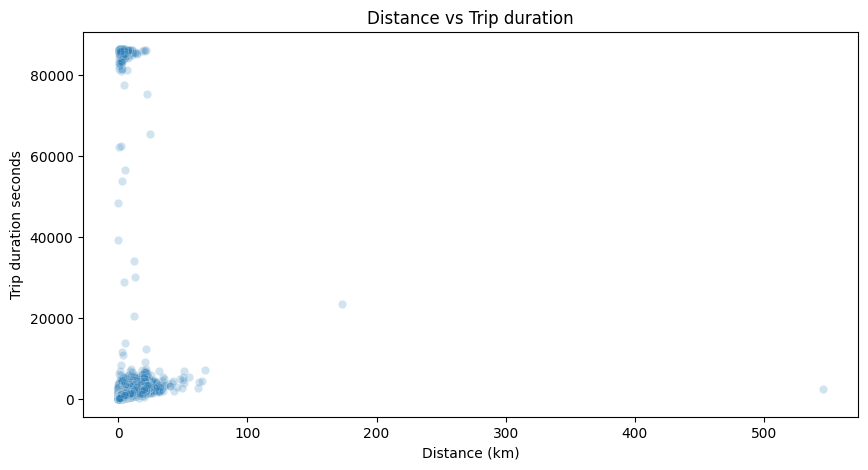

In [ ]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data = sample_df,
    x = "distance_km",
    y = "trip_duration",
    alpha = 0.2
)

plt.xlabel('Distance (km)')
plt.ylabel('Trip duration seconds')
plt.title("Distance vs Trip duration")

plt.show()



In [ ]:
zero_distance = (df['distance_km'] == 0).sum()
percentage = zero_distance / len(df) * 100

print(f"Zero-distance trips: {zero_distance:,}")
print(f"Percentage: {percentage:.3f}%")

Zero-distance trips: 5,897
Percentage: 0.404%


In [ ]:
df[df["distance_km"] == 0][
    [
        "id",
        "pickup_datetime",
        "dropoff_datetime",
        "passenger_count",
        "distance_km",
        "trip_duration"
    ]
].head(20)

,id,pickup_datetime,dropoff_datetime,passenger_count,distance_km,trip_duration
246,id3487442,2016-02-29 18:39:12,2016-02-29 18:42:59,1,0.0,227
291,id0924324,2016-05-10 18:07:52,2016-05-10 18:26:21,2,0.0,1109
407,id1145809,2016-05-16 23:15:13,2016-05-16 23:31:00,6,0.0,947
702,id3499387,2016-01-25 19:45:12,2016-01-25 19:54:52,1,0.0,580
1620,id0753277,2016-01-27 22:29:31,2016-01-27 22:29:58,1,0.0,27
1728,id2134482,2016-01-22 16:13:01,2016-01-22 16:13:20,1,0.0,19
1769,id2892749,2016-01-18 15:24:43,2016-01-18 15:28:57,5,0.0,254
2087,id0931199,2016-05-04 22:28:43,2016-05-04 22:32:51,1,0.0,248
2441,id2251007,2016-05-23 14:20:49,2016-05-23 14:20:57,1,0.0,8
2609,id1992673,2016-03-02 20:10:41,2016-03-02 20:30:53,5,0.0,1212


In [ ]:
df[df["distance_km"] == 0]["trip_duration"].describe()

,trip_duration
count,5897.000000
mean,535.515347
std,1952.094051
min,1.000000
25%,38.000000
50%,350.000000
75%,724.000000
max,86352.000000


In [ ]:
distance_thresholds = [10, 20, 50, 100, 200, 500]

for threshold in distance_thresholds:
    count = (df["distance_km"] > threshold).sum()
    percentage = count / len(df) * 100

    print(
        f">{threshold} km: "
        f"{count:,} rows "
        f"({percentage:.4f}%)"
    )

>10 km: 89,135 rows (6.1108%)
>20 km: 23,864 rows (1.6360%)
>50 km: 88 rows (0.0060%)
>100 km: 19 rows (0.0013%)
>200 km: 11 rows (0.0008%)
>500 km: 6 rows (0.0004%)


In [ ]:
df["duration_hours"] = df["trip_duration"] / 3600

In [ ]:
df["speed_kmh"] = (
    df["distance_km"] / df["duration_hours"]
)

In [ ]:
df["speed_kmh"] = np.where(
    df["trip_duration"] > 0,
    df["distance_km"] / (df["trip_duration"] / 3600),
    np.nan
)

In [ ]:
df["speed_kmh"].describe()

,speed_kmh
count,1.458644e+06
mean,1.442321e+01
std,1.497752e+01
min,0.000000e+00
25%,9.121275e+00
50%,1.279198e+01
75%,1.784491e+01
max,9.274837e+03


In [ ]:
df.nlargest(5, "speed_kmh")[
    [
        "id",
        "distance_km",
        "trip_duration",
        "speed_kmh",
        "pickup_latitude",
        "pickup_longitude",
        "dropoff_latitude",
        "dropoff_longitude"
    ]
]

,id,distance_km,trip_duration,speed_kmh,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude
1176337,id3619353,18.034405,7,9274.836731,40.764610,-73.936974,40.646858,-73.789848
910072,id1146400,578.842818,303,6877.340406,40.756634,-73.989914,36.398121,-70.346077
184925,id2306955,1240.908677,792,5640.493985,51.881084,-72.809669,40.750599,-73.987228
974378,id1510552,891.214103,611,5251.015993,35.081532,-71.799896,40.436329,-79.352837
377068,id0116374,320.125775,282,4086.712020,40.717113,-74.007095,38.946033,-76.963242


In [ ]:
# Temporal features

df["pickup_hour"] = df["pickup_datetime"].dt.hour

df["pickup_weekday"] = df["pickup_datetime"].dt.weekday

df["pickup_day"] = df["pickup_datetime"].dt.day

df["pickup_month"] = df["pickup_datetime"].dt.month

df["pickup_year"] = df["pickup_datetime"].dt.year

df["is_weekend"] = (
    df["pickup_weekday"] >= 5
).astype("int8")

df["is_rush_hour"] = (
    df["pickup_hour"].isin([7, 8, 9, 16, 17, 18, 19])
).astype("int8")

In [ ]:
df[
    [
        "pickup_datetime",
        "pickup_hour",
        "pickup_weekday",
        "pickup_day",
        "pickup_month",
        "pickup_year",
        "is_weekend",
        "is_rush_hour"
    ]
].head(10)

,pickup_datetime,pickup_hour,pickup_weekday,pickup_day,pickup_month,pickup_year,is_weekend,is_rush_hour
0,2016-03-14 17:24:55,17,0,14,3,2016,0,1
1,2016-06-12 00:43:35,0,6,12,6,2016,1,0
2,2016-01-19 11:35:24,11,1,19,1,2016,0,0
3,2016-04-06 19:32:31,19,2,6,4,2016,0,1
4,2016-03-26 13:30:55,13,5,26,3,2016,1,0
5,2016-01-30 22:01:40,22,5,30,1,2016,1,0
6,2016-06-17 22:34:59,22,4,17,6,2016,0,0
7,2016-05-21 07:54:58,7,5,21,5,2016,1,1
8,2016-05-27 23:12:23,23,4,27,5,2016,0,0
9,2016-03-10 21:45:01,21,3,10,3,2016,0,0


In [ ]:
df["pickup_hour"].value_counts().sort_index()

,count
pickup_hour,
0,53248
1,38571
2,27972
3,20895
4,15792
5,15002
6,33248
7,55600
8,67053


In [ ]:
df["is_rush_hour"] = (
    df["pickup_hour"].between(7, 9) |
    df["pickup_hour"].between(16, 19)
).astype("int8")

In [ ]:
df["vendor_id"] = df["vendor_id"].astype("category")

df["store_and_fwd_flag"] = (
    df["store_and_fwd_flag"].astype("category")
)

In [ ]:
features = [
    "vendor_id",
    "passenger_count",

    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",

    "distance_km",
    "speed_kmh",

    "pickup_hour",
    "pickup_weekday",
    "pickup_day",
    "pickup_month",
    "pickup_year",

    "is_weekend",
    "is_rush_hour",
]

X = df[features]

y = df["log_time_duration"]

In [ ]:
X

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,distance_km,speed_kmh,pickup_hour,pickup_weekday,pickup_day,pickup_month,pickup_year,is_weekend,is_rush_hour
0,2,1,-73.982155,40.767937,-73.964630,40.765602,1.498521,11.856428,17,0,14,3,2016,0,1
1,1,1,-73.980415,40.738564,-73.999481,40.731152,1.805507,9.803659,0,6,12,6,2016,1,0
2,2,1,-73.979027,40.763939,-74.005333,40.710087,6.385098,10.822201,11,1,19,1,2016,0,0
3,2,1,-74.010040,40.719971,-74.012268,40.706718,1.485498,12.465721,19,2,6,4,2016,0,1
4,2,1,-73.973053,40.793209,-73.972923,40.782520,1.188588,9.836594,13,5,26,3,2016,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1458639,2,4,-73.982201,40.745522,-73.994911,40.740170,1.225080,5.668751,13,4,8,4,2016,0,0
1458640,1,1,-74.000946,40.747379,-73.970184,40.796547,6.049836,33.251005,7,6,10,1,2016,1,1
1458641,2,1,-73.959129,40.768799,-74.004433,40.707371,7.824606,36.869870,6,4,22,4,2016,0,0
1458642,1,1,-73.982079,40.749062,-73.974632,40.757107,1.092564,10.544853,15,1,5,1,2016,0,0


In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(y.describe())

X shape: (1458644, 15)
y shape: (1458644,)

Features:
['vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'distance_km', 'speed_kmh', 'pickup_hour', 'pickup_weekday', 'pickup_day', 'pickup_month', 'pickup_year', 'is_weekend', 'is_rush_hour']

Target:
count    1.458644e+06
mean     6.466978e+00
std      7.957595e-01
min      6.931472e-01
25%      5.986452e+00
50%      6.496775e+00
75%      6.981006e+00
max      1.507575e+01
Name: log_time_duration, dtype: float64


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.30, random_state=RANDOM_STATE)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE)



In [ ]:
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (1021050, 15) (1021050,)
Validation: (218797, 15) (218797,)
Test: (218797, 15) (218797,)


In [ ]:
leakage_columns = [
    "trip_duration",
    "log_time_duration",
    "dropoff_datetime",
    "datetime_duration",
    "duration_difference"
]

print(
    [col for col in leakage_columns if col in X.columns]
)

[]


In [ ]:
# model
lgb_model = lgb.LGBMRegressor(
    objective = "regression",
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state = RANDOM_STATE,
    n_jobs=-1
)

In [ ]:
lgb_model.fit(
    X_train,
    y_train,

    eval_set=[
        (X_train, y_train),
        (X_val, y_val)
    ],

    eval_names = [
        "train",
        "valid"
    ],
    callbacks = [
        lgb.early_stopping(100),
        lgb.log_evaluation(100)
    ]
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.151067 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1615
[LightGBM] [Info] Number of data points in the train set: 1021050, number of used features: 14
[LightGBM] [Info] Start training from score 6.467067
Training until validation scores don't improve for 100 rounds
[100]	train's l2: 0.0199528	valid's l2: 0.0199416
[200]	train's l2: 0.0169206	valid's l2: 0.0180681
[300]	train's l2: 0.0154746	valid's l2: 0.0177956
[400]	train's l2: 0.0142705	valid's l2: 0.0176393
[500]	train's l2: 0.0134072	valid's l2: 0.0176234
[600]	train's l2: 0.0127253	valid's l2: 0.0175356
[700]	train's l2: 0.0120158	valid's l2: 0.0175377
Early stopping, best iteration is:
[653]	train's l2: 0.0123046	valid's l2: 0.0175017


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, n_estimators=1000,
              n_jobs=-1, objective='regression', random_state=42,
              subsample=0.8)

In [ ]:
y_pred_log = lgb_model.predict(
    X_test,
    num_iteration=lgb_model.best_iteration_
)

In [ ]:
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_squared_log_error
)

In [ ]:
mae = mean_absolute_error(y_true, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_true, y_pred)
)

r2 = r2_score(y_true, y_pred)

rmsle = np.sqrt(
    mean_squared_log_error(
        y_true,
        y_pred
    )
)

print(f"MAE:   {mae:.2f} seconds")
print(f"RMSE:  {rmse:.2f} seconds")
print(f"R²:    {r2:.4f}")
print(f"RMSLE: {rmsle:.4f}")

MAE:   30.85 seconds
RMSE:  618.92 seconds
R²:    0.9609
RMSLE: 0.1319
